<h1 style="font-family:fantasy; font-weight:500; font-size:4em; color:blue">Model Building</h1>

In [14]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score , accuracy_score ,f1_score, precision_score, recall_score , roc_curve, confusion_matrix
import joblib 

In [2]:
# import dataset using encoded dataset
df = pd.read_csv("../Datasets/hotel_df_with_encoded.csv")

In [3]:
# data head
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_day,reservation_status_month,reservation_status_year,guest_total_stay,is_stay_long,total_revenue,customer_cancel_indicator
0,1,0,342,2015,5,27,1,0,0,2,...,0,0,1,1,7,2015,0,0,0.0,0
1,1,0,737,2015,5,27,1,0,0,2,...,0,0,1,1,7,2015,0,0,0.0,0
2,1,0,7,2015,5,27,1,0,1,1,...,0,0,1,2,7,2015,1,0,75.0,0
3,1,0,13,2015,5,27,1,0,1,1,...,0,0,1,2,7,2015,1,0,75.0,0
4,1,0,14,2015,5,27,1,0,2,2,...,0,1,1,3,7,2015,2,0,196.0,0


In [4]:
# Feature that will be used to avoid any conflict with target leakage
col = ["hotel", 'lead_time' , "arrival_date_year" , "arrival_date_month" , 
       "arrival_date_week_number","arrival_date_day_of_month" , "stays_in_weekend_nights",
       "stays_in_week_nights", "adults", "children", "babies", 'meal', "country",
       'market_segment', 'distribution_channel', 'is_repeated_guest','previous_cancellations',
       'previous_bookings_not_canceled','reserved_room_type' 
       , 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 
       'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 
       'guest_total_stay', "is_stay_long"]

In [5]:
# Feature Normalization
x = df[col] # independent variable
y = df["is_canceled"] # dependent variable
std = StandardScaler()
std_x = std.fit_transform(x) # normalizing dataset 

In [6]:
# reviewing normalized data
std_x

array([[ 1.27762908,  3.02881773, -1.74905825, ..., -0.83782629,
        -1.30572393, -0.24152682],
       [ 1.27762908,  7.59755014, -1.74905825, ..., -0.83782629,
        -1.30572393, -0.24152682],
       [ 1.27762908, -0.84593001, -1.74905825, ..., -0.83782629,
        -0.94443578, -0.24152682],
       ...,
       [-0.78269978, -0.53363691,  1.16684589, ...,  3.99489704,
         1.22329307, -0.24152682],
       [-0.78269978,  0.33384393,  1.16684589, ..., -0.83782629,
         1.22329307, -0.24152682],
       [-0.78269978,  1.4442194 ,  1.16684589, ...,  1.57853537,
         1.94586936,  4.140327  ]])

In [7]:
# splitting data into train and test set 
x_train , x_test , y_train, y_test = train_test_split(std_x, y, random_state=21, train_size=0.7)
# review shape
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)
# dataset is split in ratio of 70% data goes for train purpose and 30% is for testing purpose 

(59434, 30) (59434,)
(25472, 30) (25472,)


In [19]:
# resample dataset with artificial class weight 
smote = SMOTE(random_state=11)
x_train_res , y_train_res = smote.fit_resample(x_train , y_train)
print(x_train_res.shape , y_train_res.shape)

(86508, 30) (86508,)


In [44]:
# model building 
Model = RandomForestClassifier(n_estimators=250,class_weight="balanced", min_samples_leaf=10, max_depth=30) 
# random forest classifier model with n_estimators 250 and class will be set to balanced , min_samples_leaf =10 , max depth 30
# fitting data into model or train model
Model.fit(x_train_res, y_train_res)
# predicting x test 
pred = Model.predict(x_test)

In [45]:
# score's and accuracy 
print(f"Roc_auc : {roc_auc_score(pred , y_test)}")
print(f"Accuracy Score : {accuracy_score(pred,y_test)}")
print(f"F1_Score : {f1_score(pred, y_test)}")
print(f"Precision Score: {precision_score(pred, y_test)}") # accuracy of how many positive value actually predicted by model 
print(f"Recall Score: {recall_score(pred,y_test)}") # accuracy of how many positive value are correctl predicted positive

Roc_auc : 0.7908136018655391
Accuracy Score : 0.8358589824120602
F1_Score : 0.7037902940134608
Precision Score: 0.7219476744186046
Recall Score: 0.6865238424326192


In [46]:
# confusion matrix
confusion_matrix(pred, y_test)
# true negative 16324 and false negative 1913
# true positive 4967 and false positive 2268

array([[16324,  1913],
       [ 2268,  4967]], dtype=int64)

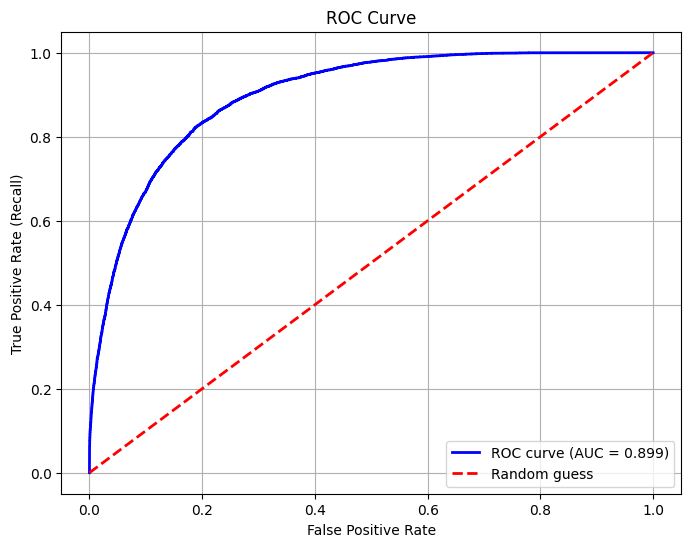

In [47]:
# plotting roc curve
y_scores= Model.predict_proba(x_test)[:,1] # getting y scores 
fpr , tpr , threshold = roc_curve(y_test, y_scores) # getting false positive rate , true positive rate
roc_auc = roc_auc_score(y_test, y_scores) # getting roc auc score which is turned out be approx 90% of the well sepration between true positive and true negative
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='red', linestyle='--', lw=2, label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [48]:
# Saving model
joblib.dump(Model, "Hotel_Booking_Model.pkl")

['Hotel_Booking_Model.pkl']